# Post-alignment local inference — injured mouse kidney

This notebook continues directly from the cross-sample kidney
workflow. It uses the final `kidney_IL3_to_NL3_aligned.h5ad`
produced by spAlignDE, with the injured `IL3` section as query and
the normal `NL3` section as reference. The analysis tests local
expression differences on a shared grid while inflating variance
where stable-gene profiles or local sampling densities indicate
weak post-alignment correspondence.

The aligned AnnData supplies spot identifiers, sample labels,
original coordinates, and the standardized `x_aligned` and
`y_aligned` columns. Local DE must use raw counts, so expression is
read from the public 10x Visium matrices and joined to the aligned
output by terminal barcode—never by row position.


## Data and execution order

Run the two kidney cross-sample notebooks first:

1. `tutorials/cross_sample/kidney/01_joint_clustering.ipynb`
2. `tutorials/cross_sample/kidney/02_alignment.ipynb`
3. this post-alignment inference notebook

Download the NL3 and IL3 Visium count matrices from the
[STcompare Zenodo record](https://zenodo.org/records/19486091),
which is the source listed in the manuscript Data Availability
section.

Required inputs:

| Input | Required content |
|---|---|
| aligned AnnData | one row per retained spot; `sample_id`, `x`, `y`, `x_aligned`, and `y_aligned` in `.obs` |
| `NL3_filtered_feature_bc_matrix.h5` | raw reference counts |
| `IL3_filtered_feature_bc_matrix.h5` | raw query counts |

The recorded example contains 3,215 NL3 spots and 2,965 IL3
spots. Reliable cell-type labels are not included in these public
inputs, so cell-type support adjustment is disabled.


## Installation and paths

From the repository root:

```bash
cd /path/to/spAlignDE
python -m pip install -e ".[tutorial]"

export SPALIGNDE_KIDNEY_ALIGNED_H5AD=/path/to/kidney_IL3_to_NL3_aligned.h5ad
export SPALIGNDE_KIDNEY_RAW_DIR=/path/to/kidney/raw
export SPALIGNDE_POST_INFERENCE_OUTPUT_DIR=/path/to/kidney/post_alignment_output
```

The first path is the output of the kidney alignment notebook; the
raw directory contains the two 10x HDF5 matrices listed above.


In [1]:
%matplotlib inline

from pathlib import Path
import os
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import t as student_t
from IPython.display import display

warnings.filterwarnings(
    "ignore",
    message="pkg_resources is deprecated as an API.*",
    category=UserWarning,
)
import spAlignDE

repository_candidates = (Path.cwd(), *Path.cwd().parents)
REPO_ROOT = next(
    (
        candidate
        for candidate in repository_candidates
        if (candidate / "pyproject.toml").exists()
        and (candidate / "src/spAlignDE.py").is_file()
    ),
    Path.cwd(),
)
ALIGNED_H5AD = Path(
    os.environ.get(
        "SPALIGNDE_KIDNEY_ALIGNED_H5AD",
        REPO_ROOT
        / "tutorials/cross_sample/kidney/output/kidney_IL3_to_NL3_aligned.h5ad",
    )
).expanduser().resolve()
RAW_DIR = Path(
    os.environ.get(
        "SPALIGNDE_KIDNEY_RAW_DIR",
        REPO_ROOT / "data/post_alignment/kidney/raw",
    )
).expanduser().resolve()
OUTPUT_DIR = Path(
    os.environ.get(
        "SPALIGNDE_POST_INFERENCE_OUTPUT_DIR",
        REPO_ROOT / "tutorials/post_alignment/kidney/output",
    )
).expanduser().resolve()
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

REFERENCE = "NL3"
QUERY = "IL3"
EXPECTED_SPOTS = {REFERENCE: 3215, QUERY: 2965}

required_files = [
    ALIGNED_H5AD,
    RAW_DIR / "NL3_filtered_feature_bc_matrix.h5",
    RAW_DIR / "IL3_filtered_feature_bc_matrix.h5",
]
missing = [path.name for path in required_files if not path.exists()]
if missing:
    raise FileNotFoundError(
        "Missing kidney tutorial inputs: " + ", ".join(missing)
    )

print("Aligned AnnData:", ALIGNED_H5AD.name)
print("Raw matrices:", [path.name for path in required_files[1:]])
print("Output directory:", OUTPUT_DIR.name)


Aligned AnnData: kidney_IL3_to_NL3_aligned.h5ad
Raw matrices: ['NL3_filtered_feature_bc_matrix.h5', 'IL3_filtered_feature_bc_matrix.h5']
Output directory: spalignde-post-inference-output


## 1. Build the validated alignment-to-inference handoff

`spAlignDE.build_visium_inference_table` treats the alignment output
as the authoritative geometry handoff, reads the public raw 10x
matrices, matches spots by terminal barcode, selects the broad
mismatch-risk gene pool, and returns the standard long table used
by `prepare_inference`. The query uses its deformed coordinates,
whereas the reference remains fixed.


In [2]:
genes_to_test = ["Cbr1", "Cd44", "Myo5a"]
visium_input = spAlignDE.build_visium_inference_table(
    ALIGNED_H5AD,
    {
        REFERENCE: RAW_DIR / "NL3_filtered_feature_bc_matrix.h5",
        QUERY: RAW_DIR / "IL3_filtered_feature_bc_matrix.h5",
    },
    genes=genes_to_test,
    min_detected_spots=10,
    min_total_counts=10,
    batch="kidney_pair",
)
coordinate_data = visium_input.coordinates
inference_data = visium_input.data
risk_genes = list(visium_input.risk_genes)

if visium_input.sample_sizes != EXPECTED_SPOTS:
    raise ValueError(
        f"Expected spot counts {EXPECTED_SPOTS}, "
        f"observed {visium_input.sample_sizes}."
    )

coordinate_summary = coordinate_data.groupby("sample_id").agg(
    spots=("barcode", "size"),
    x_aligned_min=("x_aligned", "min"),
    x_aligned_max=("x_aligned", "max"),
    y_aligned_min=("y_aligned", "min"),
    y_aligned_max=("y_aligned", "max"),
)
display(coordinate_summary)


,spots,x_aligned_min,x_aligned_max,y_aligned_min,y_aligned_max
sample_id,,,,,
IL3,2965,7.226536,66.510723,-1.340054,126.880625
NL3,3215,7.000000,65.000000,0.000000,127.000000


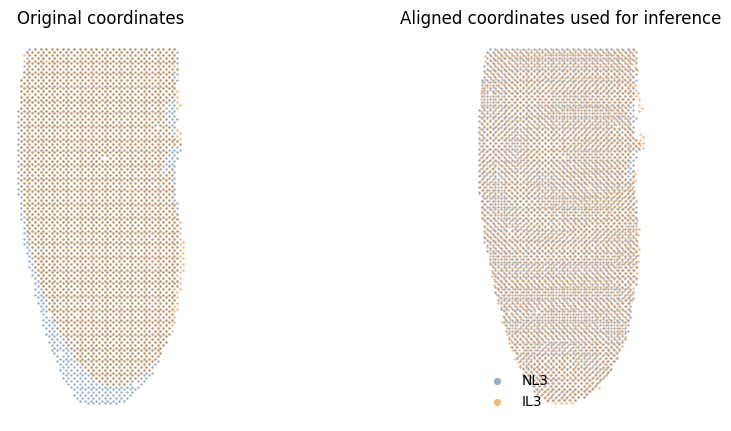

In [3]:
colors = {REFERENCE: "#4C78A8", QUERY: "#F58518"}
figure, axes = plt.subplots(1, 2, figsize=(9.2, 4.2), constrained_layout=True)
for sample_id in (REFERENCE, QUERY):
    sample = coordinate_data.loc[
        coordinate_data["sample_id"].eq(sample_id)
    ]
    axes[0].scatter(
        sample["x"], sample["y"], s=3, alpha=0.60,
        linewidths=0, color=colors[sample_id], label=sample_id,
        rasterized=True,
    )
    axes[1].scatter(
        sample["x_aligned"], sample["y_aligned"], s=3, alpha=0.60,
        linewidths=0, color=colors[sample_id], label=sample_id,
        rasterized=True,
    )
axes[0].set_title("Original coordinates")
axes[1].set_title("Aligned coordinates used for inference")
for axis in axes:
    axis.set_aspect("equal")
    axis.set_axis_off()
axes[1].legend(frameon=False, markerscale=3, loc="best")
plt.show()


## 2. Inspect the barcode-matched raw-expression input

`adata.X` in an alignment output may contain normalized features
used upstream. It is therefore not assumed to be raw expression.
The package function reads the two public 10x matrices, makes gene
names unique, orders rows by the barcodes in the alignment output,
and stops on missing or duplicated identifiers.


In [4]:
handoff_summary = pd.DataFrame(
    {"matched spots": visium_input.sample_sizes}
)
handoff_summary.index.name = "sample_id"
display(handoff_summary)
print("Common raw-count genes:", visium_input.n_common_genes)
print("Barcode matching: one-to-one validation passed")


,matched spots
sample_id,
NL3,3215
IL3,2965


Common raw-count genes: 32285
Barcode matching: one-to-one validation passed


## 3. Select stable-gene candidates and assemble inference input

The package handoff retains genes detected in at least 10 spots
with at least 10 total counts across the pair for mismatch-risk
estimation. This broad pool is separate from the three genes tested
in the tutorial. Spot-wise normalization to 10,000 is applied later
inside `prepare_inference`.


In [5]:
TARGET_LIBRARY_SIZE = 10_000

display(
    pd.DataFrame(
        {
            "quantity": [
                "spots", "shared genes", "risk genes", "genes tested"
            ],
            "value": [
                len(inference_data), visium_input.n_common_genes,
                len(risk_genes), ", ".join(genes_to_test),
            ],
        }
    )
)


,quantity,value
0,spots,6180
1,shared genes,32285
2,risk genes,16446
3,genes tested,"Cbr1, Cd44, Myo5a"


## 4. Construct the shared grid and mismatch-risk map

`prepare_inference` constructs the fixed testing grid, local
neighborhoods, density summaries, and stable-gene distributional
mismatch risk. The density channel contributes 0.75 of the risk
energy in this recorded kidney analysis because local sampling-density
mismatch is an important reliability signal for these aligned sections.
This is a dataset-specific recorded setting, not a universal default.
By default, the R-driven grid
resolution is retained when the actual number of tissue-valid
locations lies between the median per-sample spot count,
$N_{typ}$, and $2N_{typ}$. Otherwise, the resolution is moved
toward the nearest bound using the same tissue mask that defines
the final grid. Set `GRID_N` only when an explicit resolution is
scientifically justified.


[INFO] detecting tissue geometry on 6180 spots ...


[INFO] geometry ready: 0 holes, 6187 grid points, R=3.837, h_grid=1.51, R_map=2.265


[INFO] building KNN trees for 2 samples ...


[SWND] N_A=3215, N_B=2965, G=16446


[marker-screen] var_thr=0.00675779 | delta_thr=0.05 | cor_min=0.2 | n_var=8223 | n_delta=11046 | n_cor=2664 | n_all=632


,value
reference,NL3
query,IL3
grid resolution (n x n),86
grid resolution source,two_n_typ_upper_bound
median spots per sample (N_typ),3090.0
target tissue-valid locations,"(3090.0, 6180.0)"
shared grid locations,6187
grid spacing,1.509883
risk-map radius,2.264824


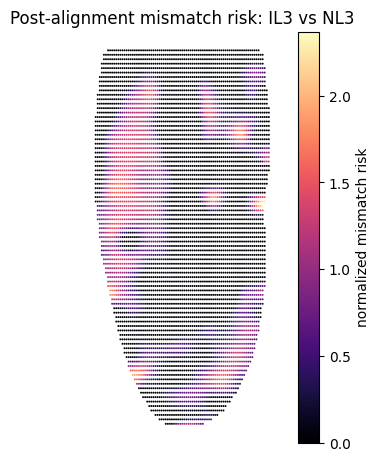

In [6]:
GRID_N = None  # integer >= 2 overrides automatic grid resolution

prepared = spAlignDE.prepare_inference(
    inference_data,
    reference=REFERENCE,
    genes=genes_to_test,
    risk_genes=risk_genes,
    aligned_coordinate_key=("x_aligned", "y_aligned"),
    cell_type_key=None,
    density_energy_share=0.75,
    library_size=TARGET_LIBRARY_SIZE,
    grid_n=GRID_N,
    n_jobs=1,
    random_state=1,
)

preparation_summary = pd.DataFrame(
    {
        "value": {
            "reference": prepared.reference,
            "query": ", ".join(prepared.shared["time_ids"]),
            "grid resolution (n x n)": prepared.metadata["grid_n"],
            "grid resolution source": prepared.metadata["grid_n_source"],
            "median spots per sample (N_typ)": prepared.metadata["n_typ"],
            "target tissue-valid locations": prepared.metadata[
                "target_grid_locations"
            ],
            "shared grid locations": len(prepared.shared["grid_eval"]),
            "grid spacing": prepared.metadata["shared_grid_spacing"],
            "risk-map radius": prepared.metadata["risk_map_radius"],
        }
    }
)
display(preparation_summary)

grid = prepared.shared["grid_eval"][["x", "y"]].to_numpy(float)
mismatch_risk = np.asarray(prepared.shared["risk_time"][QUERY], dtype=float)
figure, axis = plt.subplots(figsize=(5.2, 4.5), constrained_layout=True)
artist = axis.scatter(
    grid[:, 0], grid[:, 1], c=mismatch_risk, s=2.0,
    cmap="magma", linewidths=0, rasterized=True,
)
axis.set_title("Post-alignment mismatch risk: IL3 vs NL3")
axis.set_aspect("equal")
axis.set_axis_off()
figure.colorbar(artist, ax=axis, label="normalized mismatch risk")
plt.show()


### How to adapt the inference settings

- Keep `risk_genes` broad and independent of the genes being tested;
  do not estimate residual mismatch from only a few target genes.
- Increase `min_detected_spots` or `min_total_counts` when extremely
  sparse genes make the risk map unstable.
- `density_energy_share` must be between zero and one. Increase it
  only when sampling-density discordance is a meaningful reliability
  signal; it must not be used to conceal poor alignment.
- Leave `GRID_N=None` for the sample-size-aware automatic rule. An
  explicit `grid_n` is the number of Cartesian points per axis, not
  the number of retained tissue locations. Higher values improve
  spatial resolution but increase runtime and memory.
- Enable cell-type adjustment only when complete, validated
  annotations exist for every sample. Record whether
  `region_cleanup` is enabled because it changes connected
  significant regions. The recorded kidney analysis leaves it disabled
  so the displayed significance masks are the direct FDR results.

Inspect aligned geometry, local support, grid resolution, and
mismatch risk together before interpreting differential-expression
maps.


## 5. Fit mismatch-aware local differential expression

The model tests whether each local contrast departs from the
comparison-wide baseline after optional spatial technical
adjustment. Stable-gene and density mismatch risk inflates local
variance without changing the estimated contrast. BH adjustment is
performed separately for each gene across valid grid locations.
`cell_type_adjustment=False` reflects the available public inputs;
users with complete, validated cell-type labels may enable it.


In [7]:
result = spAlignDE.fit_local_de(
    prepared,
    genes=genes_to_test,
    contrast="vs_reference",
    mismatch_aware=True,
    technical_adjustment=True,
    cell_type_adjustment=False,
    global_offset=False,
    region_cleanup=False,
    n_jobs=1,
    random_state=1,
    verbose=True,
)


[batch_run] completed 3 / 3 genes


## 6. Inspect and save local results

Each output row represents one shared-grid location. A positive
statistic indicates higher adjusted local expression in IL3 than
NL3; a negative statistic indicates the reverse. Red contours in
the figures enclose FDR-significant grid locations with region cleanup
disabled. The gene-level ACAT P value combines dependent local P
values over valid grid locations. It is an omnibus P value for a
spatial change somewhere on the grid, not a local P value or a
genome-wide FDR-adjusted gene-discovery value.


,gene,contrast,gene-level ACAT P value,significant grid locations,minimum q-value,median |t|
0,Cbr1,IL3 - NL3,1.482148e-14,3482,1.208891e-31,3.222170
1,Cd44,IL3 - NL3,2.475714e-06,1629,7.677504e-06,1.801929
2,Myo5a,IL3 - NL3,5.284662e-14,2996,7.076749e-21,2.408258


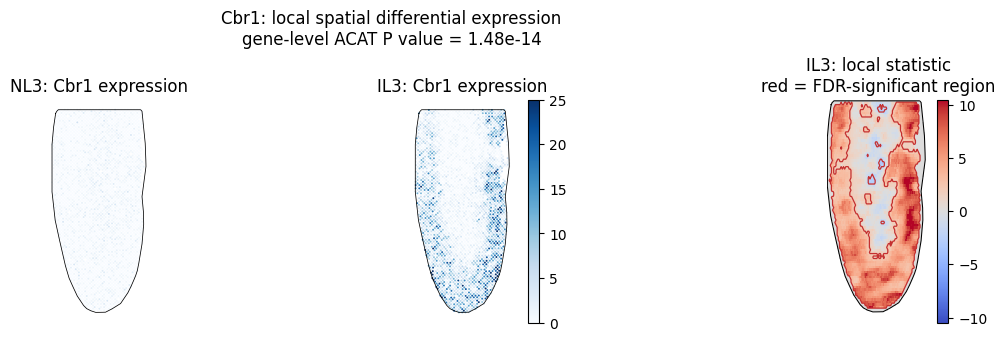

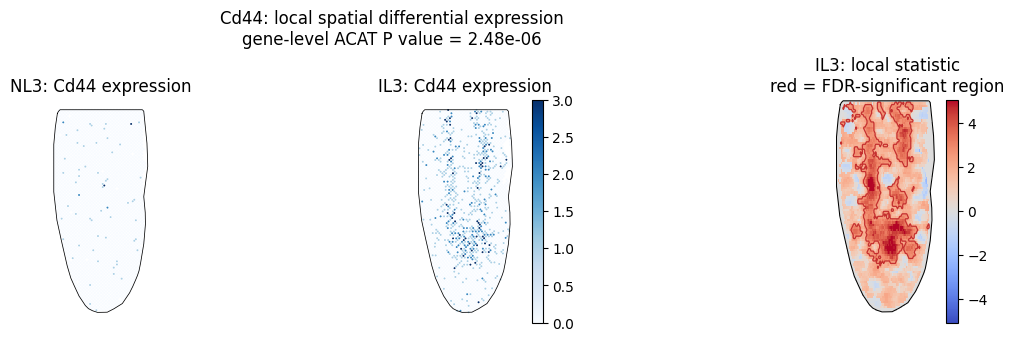

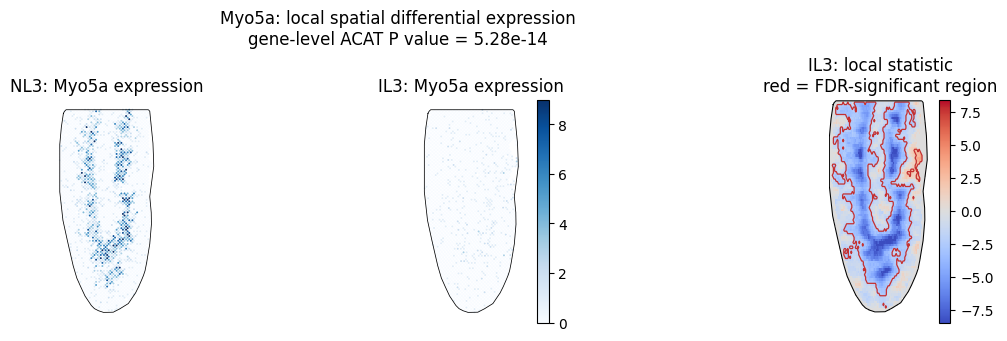

In [8]:
summary_rows = []
grid_table = prepared.shared["grid_eval"][["x", "y"]].reset_index(drop=True)
for gene, fit in result.fits.items():
    gene_acat_pvalue = spAlignDE.gene_level_acat_pvalue(result, gene)
    terrain = fit["terrain_data"]
    statistic = np.asarray(terrain["stat_by_time"][QUERY], dtype=float)
    degrees_of_freedom = np.asarray(
        terrain["df_by_time"][QUERY], dtype=float
    )
    p_value = 2.0 * student_t.sf(
        np.abs(statistic), degrees_of_freedom
    )
    q_value = np.asarray(terrain["q_by_time"][QUERY], dtype=float)
    significant = np.asarray(
        terrain["sig_mask_by_time"][QUERY], dtype=bool
    )
    summary_rows.append(
        {
            "gene": gene,
            "contrast": f"{QUERY} - {REFERENCE}",
            "gene-level ACAT P value": gene_acat_pvalue,
            "significant grid locations": int(significant.sum()),
            "minimum q-value": float(np.nanmin(q_value)),
            "median |t|": float(np.nanmedian(np.abs(statistic))),
        }
    )
    output = grid_table.assign(
        statistic=statistic,
        p_value=p_value,
        q_value=q_value,
        significant=significant,
    )
    output.to_csv(
        OUTPUT_DIR / f"{gene}_{QUERY}_vs_{REFERENCE}_local_de.csv.gz",
        index=False,
    )

result_summary = pd.DataFrame(summary_rows)
result_summary.to_csv(
    OUTPUT_DIR / "kidney_local_de_summary.csv", index=False
)
display(result_summary)

for gene in genes_to_test:
    figure = spAlignDE.plot_local_result(
        result,
        gene,
        show_expression=True,
        invert_y=False,
    )
    plt.show()


## Output contract and interpretation

The notebook returns the in-memory `PreparedInference` object
(`prepared`) and fitted `LocalDEResult` (`result`). It also writes
one compressed grid table per gene with `x`, `y`, `statistic`,
`p_value`, `q_value`, and `significant`, plus
`kidney_local_de_summary.csv`, which also records the gene-level
ACAT omnibus P value.

This is a matched-section IL3-versus-NL3 analysis, not
replicate-level population inference. The representative genes
reproduce the same principal spatial conclusions as the previous
kidney coordinate workflow. For multiple query samples, reuse the
prepared shared-grid design and summarize gene-level evidence or
ordered trajectories with `gene_level_acat_pvalue` and
`cluster_trajectories`.
